In [1]:
import requests
from bs4 import BeautifulSoup
from urllib.parse import urljoin
from typing import Annotated
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from dotenv import load_dotenv
from IPython.display import Image, display
import gradio as gr
from langchain_openai import ChatOpenAI
from pydantic import BaseModel
import os
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver
# from langchain_community.utilities import GoogleSerperAPIWrapper
from typing import TypedDict




In [2]:
memory = MemorySaver()

load_dotenv(override=True)
api_key=os.getenv("OPENROUTER_API_KEY")

In [16]:
# @tool
def get_latest_releases(limit: int | None = None):
    """Return the latest ABS releases."""
    
    url = "https://www.abs.gov.au/release-calendar/latest-releases"

    try: 
        response = requests.get(url, timeout=30)
    except requests.RequestException as e:
        print(f"Error fetching latest releases: {e}")
        return []
    response.raise_for_status()
    print('retrieving latest pages')

    soup = BeautifulSoup(response.content, "html.parser")
    releases = []

    items = soup.find_all(class_="views-row")

    print(len(items), 'items found')
    if limit is not None:
        items = items[:limit]

    for item in items:
        heading = item.find("h3")
        link = heading.find("a") if heading else None
        time = item.find("time")

        if link and link.get("href"):
            releases.append({
                "date": time.get_text(" ", strip=True) if time else None,
                "title": link.get_text(" ", strip=True),
                "url": urljoin(url, link["href"]),
            })

    return releases

In [17]:
# @tool
def get_full_release_text(url: str,get_full = False):
    """ Return the full text of an ABS release given its URL.
    use get_full = True to return the full text of the release, otherwise only key statistics will be returned.
    """
    try: 
        response = requests.get(url, timeout=30)
    except requests.RequestException as e:
        print(f"Error fetching release text: {e}")
        return {"key_statistics": "Error fetching release text."}
    response.raise_for_status()
    print('retrieving text from url:', url)
    soup = BeautifulSoup(response.content, "html.parser")

    if soup.find(class_="field-key-statistics") == None:
        key_statistics = "No key statistics found."
    else:
        key_statistics = soup.find(class_="field-key-statistics").text

    if get_full == False:
        return {"key_statistics": key_statistics}

    print('retrieving full text from url:', url)
    
    full_text = soup.find(id="content").text

    return {"key_statistics": key_statistics, "full_text": full_text}

In [13]:
tools = [get_latest_releases,get_full_release_text]

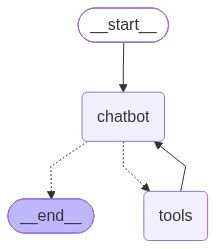

In [14]:
# Step 1: Define the State object
class State(TypedDict):
    messages: Annotated[list, add_messages]


# Steps 1 and 2
graph_builder = StateGraph(State)


# Step 3
llm = ChatOpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=api_key,
    model="qwen/qwen3.7-flash"
)


llm_with_tools = llm.bind_tools(tools)

def chatbot(state: State):
    # print(state)
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

graph_builder.add_node("chatbot", chatbot)
graph_builder.add_node("tools", ToolNode(tools=tools))

# Step 4
graph_builder.add_conditional_edges( "chatbot", tools_condition, "tools")
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)

# Step 5
graph = graph_builder.compile(checkpointer=memory)
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
config = {"configurable": {"thread_id": "1"}}

def chat(user_input: str, history):
    result = graph.invoke({"messages": [{"role": "user", "content": user_input}]}, config=config)
    return result["messages"][-1].content


gr.ChatInterface(chat).launch()

* Running on local URL:  http://127.0.0.1:7865
* To create a public link, set `share=True` in `launch()`.


retrieving latest pages
20 items found
retrieving text from url: https://www.abs.gov.au/statistics/industry/building-and-construction/building-approvals-australia/jul-2026
retrieving full text from url: https://www.abs.gov.au/statistics/industry/building-and-construction/building-approvals-australia/jul-2026


In [37]:
urls = [link['url'] for link in get_latest_releases(limit=5)]

retrieving latest pages
20 items found


In [39]:
urls

['https://www.abs.gov.au/statistics/labour/labour-accounts/labour-account-australia/jun-2026',
 'https://www.abs.gov.au/media-centre/media-releases/filled-jobs-rise-07-june-quarter',
 'https://www.abs.gov.au/articles/labour-account-modelled-state-and-territory-estimates-industry-2026',
 'https://www.abs.gov.au/statistics/economy/national-accounts/modellers-database/jun-quarter-2026',
 'https://www.abs.gov.au/statistics/economy/international-trade/international-trade-goods/jul-2026']

In [43]:
# url = "https://www.abs.gov.au/statistics/industry/building-and-construction/building-approvals-australia/jul-2026"

for i in urls:
    print(i)

    response = requests.get(i, timeout=30)
    response.raise_for_status()



    # print('retrieving text from url:', url)
    soup = BeautifulSoup(response.content, "html.parser")

    tables = soup.find_all('table')
    print(len(tables))
    # print(tables.text)



https://www.abs.gov.au/statistics/labour/labour-accounts/labour-account-australia/jun-2026
14
https://www.abs.gov.au/media-centre/media-releases/filled-jobs-rise-07-june-quarter
3
https://www.abs.gov.au/articles/labour-account-modelled-state-and-territory-estimates-industry-2026
16
https://www.abs.gov.au/statistics/economy/national-accounts/modellers-database/jun-quarter-2026
0
https://www.abs.gov.au/statistics/economy/international-trade/international-trade-goods/jul-2026
26


In [ ]:
# 

In [30]:
len(tables)

8

In [34]:
for table in tables:
    print(table.text)
    print('\n')

July key figures Jul 26 (no.)Monthly change (%)Yearly change (%)Seasonally adjusted  Total dwelling units approved17,687-3.69.0 Private sector houses10,199-4.26.0 Private sector dwellings excluding houses7,119-0.419.9Trend  Total dwelling units approved18,3650.811.7 Private sector houses10,4710.011.9 Private sector dwellings excluding houses7,4872.312.5


Dwelling units approved (a)Seasonally adjusted (no.)Trend (no.)Jul-1113,08913,042Aug-1114,36412,835Sep-1112,60112,552Oct-1111,66212,211Nov-1111,89911,791Dec-1111,95411,388Jan-1210,85811,244Feb-1211,53411,425Mar-1211,79111,792Apr-1210,92412,219May-1213,96712,694Jun-1214,83313,178Jul-1211,80913,639Aug-1213,02714,010Sep-1215,75114,226Oct-1214,60014,209Nov-1214,24914,017Dec-1214,37113,766Jan-1312,04713,505Feb-1313,55013,374Mar-1313,33713,432Apr-1314,92013,685May-1314,33314,079Jun-1313,62414,618Jul-1315,05215,274Aug-1314,74615,992Sep-1319,04116,710Oct-1317,86617,247Nov-1317,69817,450Dec-1317,36017,302Jan-1416,84216,961Feb-1416,66016,607Mar